In [2]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
import pyEXP 
import nba
import EXPtools
import gala.potential as gp
import os
plt.style.use("../../../../visualizations/matplotlib.mplstyle")
import scipy.differentiate as differentiate

In [3]:
os.chdir('../basis/')

In [4]:
# Global variables:
MODELS = ['MW', 'MWLMC3b0', 'MWLMC3b1', 'MWLMC4b0', 'MWLMC4b1', 'MWLMC5b1', 'MWLMC5b0', 'MWLMC6b0', 'MWLMC6b1']
BASIS_NAME = 'GC21_MW_DM_halo_10_8.yaml' 
COEFS_PATH = '../coefficients/'
#SNAP_NAME = 'MW_100M_beta1_vir_OM3_G4_110.hdf5'


In [5]:
# Load basis:
GC21_basis = EXPtools.load_basis(BASIS_NAME)

---- SLGridSph::ReadH5Cache: successfully read basis cache <cache_GC21_MW_DM_halo_10_8.h5>
---- Spherical::orthoTest: worst=0.0158575


In [6]:
def load_coefficients(suite, model):
    if suite == 'GC21':
        coefs_name = COEFS_PATH + "coefs_GC21_{}_DM_halo_10_8.h5".format(model)
        coefs = pyEXP.coefs.Coefs.factory(coefs_name)
        times = coefs.Times()
    power = coefs.Power()
    Pmon = power[:,0]
    Pdipole = power[:,1]
    Pquad = power[:,2]
    return times, Pmon, Pdipole, Pquad

In [8]:
tmw, P0mw, p1mw, p2mw = load_coefficients("GC21", "MW")
tmwlmc3, P0mwlmc3, p1mwlmc3, p2mwlmc3 = load_coefficients("GC21", "MWLMC3b0")
#tmw, P0mw, p1mw, p2mw = load_coefficients("GC21", "MW")

Text(0, 0.5, '$\\rm{Coefficients\\ relative\\ power}$')

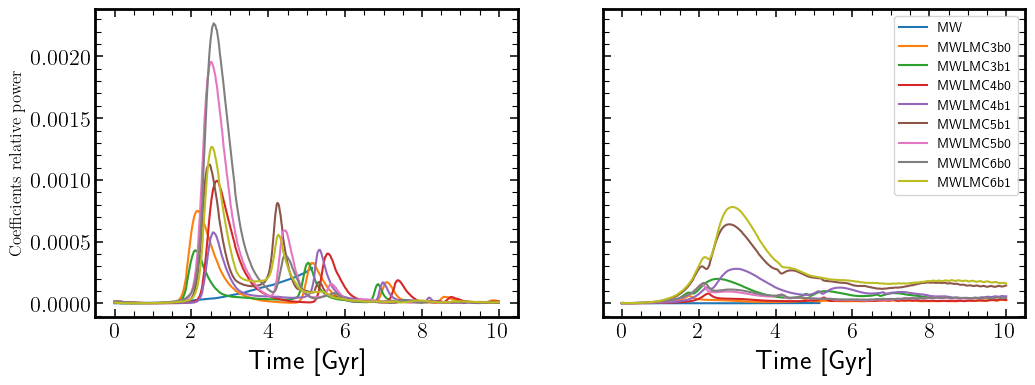

In [9]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
for m in MODELS:
    t, p0, p1, p2 = load_coefficients("GC21", m)
    ax[0].plot(t, p1/p0, label=m, lw=1.5)
    ax[1].plot(t, p2/p0, label=m, lw=1.5)

plt.legend()
#ax[0].set_yscale('log')
ax[0].set_xlabel('Time [Gyr]', fontsize=20)
ax[1].set_xlabel('Time [Gyr]', fontsize=20)
ax[0].set_ylabel(r'$\rm{Coefficients\ relative\ power}$', fontsize=12)

(0.0, 2.0)

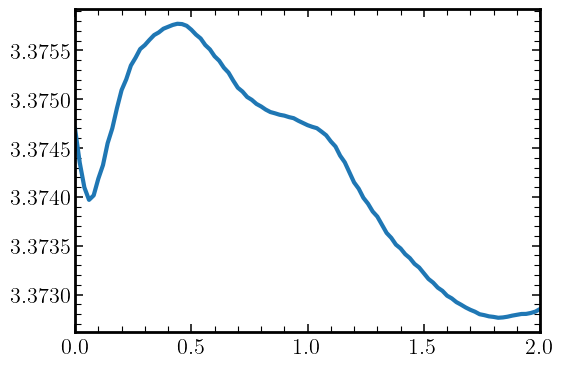

In [22]:
plt.plot(tmw, np.log10(P0mw))
#plt.plot(tmw, np.log10(p1mw))
#plt.plot(tmw, np.log10(p2mw))
plt.xlim(0, 2)


In [23]:
Mlmc = np.array([0.8e11, 0.8e11, 1.0e11, 1.0e11, 1.e11, 1.8e11, 2.5e11, 2.5e11])
Mmw = 1.57e12

In [ ]:
import scipy.differentiate as differentiate

In [ ]:
f = scipy.interpolate.interp1d(t, p1/p0)
tinterp = np.linspace(np.min(t[1:]), np.max(t[:-1]), 200)

In [ ]:
f(tinterp)

In [ ]:
tinterp

In [ ]:
dp1 = differentiate.derivative(f, tinterp[10:-10])

In [ ]:
#def dipole_peak()

In [107]:
tmin = tinterp[np.argmax(dp1.df)]
print(tmin)
tpeak = t[np.argmax(p1/p0)]
print(tpeak)
print(tpeak-tmin)


1.8218090452261309
2.54
0.7181909547738692


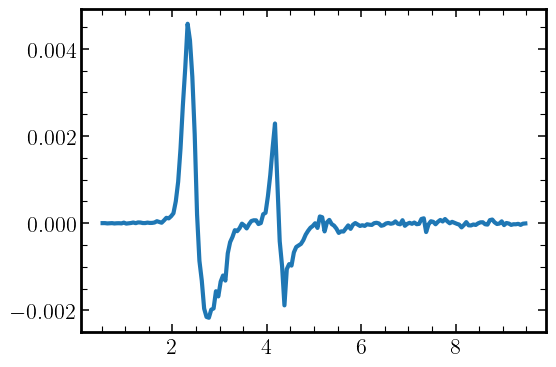

In [104]:
plt.plot(tinterp[10:-10], dp1.df)

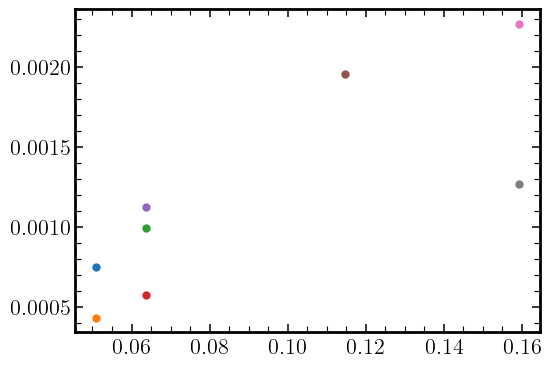

In [108]:
i=0
p1p0 = np.zeros(8)
mratio = np.zeros(8)
for m in ['MWLMC3b0', 'MWLMC3b1', 'MWLMC4b0', 'MWLMC4b1', 'MWLMC5b1', 'MWLMC5b0', 'MWLMC6b0', 'MWLMC6b1']:
    t, p0, p1, p2 = load_coefficients("GC21", m)
    tmax = np.argmax(p1/p0)
    mratio[i] = Mlmc[i]/Mmw
    p1p0[i] = np.max(p1/p0) 
    plt.scatter(Mlmc[i]/Mmw, np.max(p1/p0))
    i+=1

In [109]:
np.savetxt('gc21_dipole_ratios.txt', np.array([p1p0, mratio]))

In [1]:
p1p0

NameError: name 'p1p0' is not defined

In [54]:
npoints=40
time=2.0
ymin=-200
ymax=200
zmin=-200
zmax=200

x = np.linspace(-100 , 100)
grid = np.meshgrid(x, x)
grid[0].shape

(50, 50)

In [55]:
xyz_grid = EXPtools.visuals.Grid3D('cartesian', ranges=[(-10,10), (ymin, ymax), (zmin, zmax)], num_points=npoints)
xyz_grid = xyz_grid.to('cartesian')
fields = pyEXP.field.FieldGenerator([time], xyz_grid)

In [56]:
rho_mw = fields.points(GC21_basis, MW_GC21_coefs)[time]['dens'].reshape((npoints, npoints, npoints))[0]

In [57]:
rho_mwmc = fields.points(GC21_basis, MWLMC_GC21_coefs)[time]['dens'].reshape((npoints, npoints, npoints))[0]

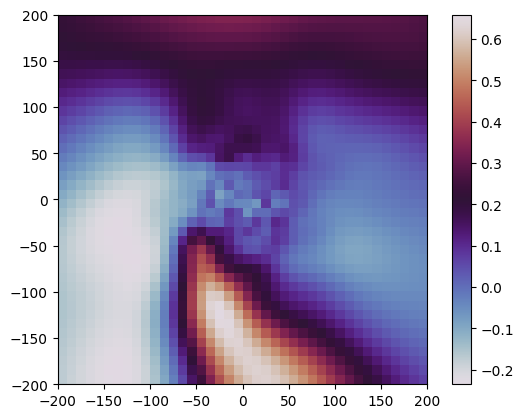

In [59]:
plt.imshow((np.abs(rho_mwmc/rho_mw))-1, extent=[ymin, ymax, zmin, zmax], cmap='twilight')
plt.colorbar()

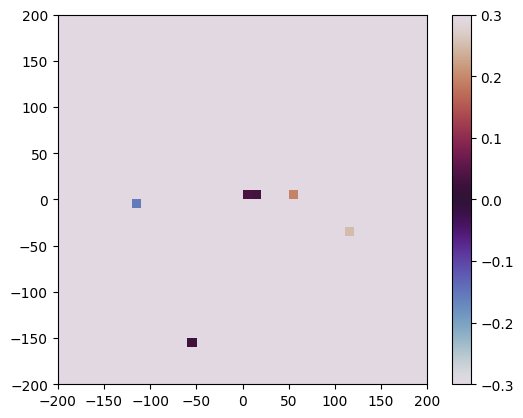

In [78]:
plt.imshow((rho/rho_mon)-1, extent=[ymin, ymax, zmin, zmax], cmap='twilight', vmin=-0.3, vmax=0.3)
plt.colorbar()

In [57]:
def spherical_density_profile(basis, coefs, r, npoints=5):
    spherical_grid = EXPtools.visuals.Grid3D('spherical', ranges=[(r,r+0.001), None, None], num_points=npoints)
    xyz_sph = spherical_grid.to('cartesian')
    fields = pyEXP.field.FieldGenerator([1.0], xyz_sph)
    sph_fields = fields.points(basis, coefs)[1.0]['dens m=0']
    sph_fields_all = fields.points(basis, coefs)[1.0]['dens']
    return np.mean(sph_fields), np.mean(sph_fields_all)

In [58]:
rbins = np.linspace(0, 300, 300)
bfe_dens_profile = np.zeros_like(rbins)
MWLMC_bfe_dens_profile = np.zeros_like(rbins)

In [ ]:
for i in range(len(rbins)):
    _ , bfe_dens_profile[i] = spherical_density_profile(GC21_basis, GC21_coefs, rbins[i])


In [59]:
for i in range(len(rbins)):
    _ , MWLMC_bfe_dens_profile[i] = spherical_density_profile(GC21_basis, GC21_coefs, rbins[i])


In [60]:
Hern_anpot = gp.HernquistPotential(m=157.0, c=40.85)
grid = np.zeros((3, len(rbins)))
grid[0] = rbins
Hern_profile = Hern_anpot.density(grid)

/home/ngc/Work/research/codes/environments/pyexp310/lib/python3.10/site-packages/astropy/units/quantity.py:671: RuntimeWarning: invalid value encountered in multiply
  result = super().__array_ufunc__(function, method, *arrays, **kwargs)


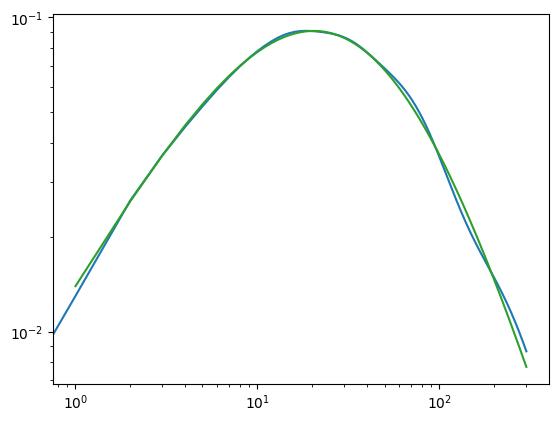

In [62]:
plt.loglog(rbins, MWLMC_bfe_dens_profile*rbins**2)
plt.loglog(rbins, bfe_dens_profile*rbins**2)
plt.loglog(rbins, Hern_profile*rbins**2)